# Training Cat/No-cat audio model

https://www.kaggle.com/datasets/mmoreaux/audio-cats-and-dogs?resource=download

https://www.kaggle.com/datasets/haithammoh/sounds-of-animals

https://www.kaggle.com/datasets/javohirtoshqorgonov/noise-audio-data

https://www.kaggle.com/datasets/andrewmvd/cat-meow-classification

In [1]:
!pip install kaggle kagglehub
!pip install librosa soundfile pandas numpy

In [2]:
import kagglehub

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
datasets = {
    "cats-and-dogs": "mmoreaux/audio-cats-and-dogs",
    "animal_sounds": "haithammoh/sounds-of-animals",
    "noise_audio": "javohirtoshqorgonov/noise-audio-data",
    "cat_meow": "andrewmvd/cat-meow-classification"
}

In [4]:
datasets_local_path = {}
for name, kaggle_path in datasets.items():
  local_path = kagglehub.dataset_download(kaggle_path)

  datasets_local_path[name] = local_path
  print(f"Path to {name} dataset files: {local_path}")

Path to cats-and-dogs dataset files: /Users/viktorzozula/.cache/kagglehub/datasets/mmoreaux/audio-cats-and-dogs/versions/5
Path to animal_sounds dataset files: /Users/viktorzozula/.cache/kagglehub/datasets/haithammoh/sounds-of-animals/versions/1
Path to noise_audio dataset files: /Users/viktorzozula/.cache/kagglehub/datasets/javohirtoshqorgonov/noise-audio-data/versions/1
Path to cat_meow dataset files: /Users/viktorzozula/.cache/kagglehub/datasets/andrewmvd/cat-meow-classification/versions/1


In [5]:
datasets_local_path

{'cats-and-dogs': '/Users/viktorzozula/.cache/kagglehub/datasets/mmoreaux/audio-cats-and-dogs/versions/5',
 'animal_sounds': '/Users/viktorzozula/.cache/kagglehub/datasets/haithammoh/sounds-of-animals/versions/1',
 'noise_audio': '/Users/viktorzozula/.cache/kagglehub/datasets/javohirtoshqorgonov/noise-audio-data/versions/1',
 'cat_meow': '/Users/viktorzozula/.cache/kagglehub/datasets/andrewmvd/cat-meow-classification/versions/1'}

# Об'єднання, очищення, дослідження та вилучення фіч

In [6]:
import pandas as pd
import os
from IPython.display import Audio, display

## Noise dataset

In [7]:
METADATA_PATH = f"{datasets_local_path['noise_audio']}/ESC-50-master/meta/esc50.csv"
AUDIO_FOLDER = f"{datasets_local_path['noise_audio']}/ESC-50-master/audio"

# Завантаження метаданих
df_1 = pd.read_csv(METADATA_PATH)
df_1['filepath'] = df_1['filename'].apply(lambda x: os.path.join(AUDIO_FOLDER, x))

# Стовпці, які нас цікавлять: 'filepath' та 'category' (наш клас)
df_1 = df_1[['filepath', 'category', 'fold']]

print("DataFrame ESC-50 створено:")
print(df_1.head())
print(f"Загальна кількість записів: {len(df_1)}")
print(f"Кількість унікальних класів: {df_1['category'].nunique()}")

DataFrame ESC-50 створено:
                                            filepath        category  fold
0  /Users/viktorzozula/.cache/kagglehub/datasets/...             dog     1
1  /Users/viktorzozula/.cache/kagglehub/datasets/...  chirping_birds     1
2  /Users/viktorzozula/.cache/kagglehub/datasets/...  vacuum_cleaner     1
3  /Users/viktorzozula/.cache/kagglehub/datasets/...  vacuum_cleaner     1
4  /Users/viktorzozula/.cache/kagglehub/datasets/...    thunderstorm     1
Загальна кількість записів: 2000
Кількість унікальних класів: 50


In [8]:
record = df_1.sample(1)

print(f"Label: {record['category']}")
display(Audio(record['filepath'].values[0]))

Label: 1665    car_horn
Name: category, dtype: object


## Sounds of animals

In [9]:
def create_dataframe_from_folders(root_path):
    """
    Сканує кореневу папку, використовуючи імена підпапок як мітки класів,
    та створює DataFrame з filepath, filename та class.

    :param root_path: Коренева директорія, що містить підпапки-мітки.
    :return: Pandas DataFrame.
    """

    # 1. Нормалізація кореневого шляху та перевірка існування
    root_path = os.path.abspath(root_path)
    if not os.path.isdir(root_path):
        print(f"❌ Помилка: Директорію не знайдено за шляхом: {root_path}")
        return pd.DataFrame()

    audio_data = []
    audio_extensions = ('.wav', '.mp3', '.ogg', '.flac')

    # 2. Сканування кореневої папки для отримання міток (підпапок)
    # Кожна підпапка вважається окремим класом
    label_dirs = [d for d in os.listdir(root_path)
                  if os.path.isdir(os.path.join(root_path, d))]

    if not label_dirs:
        print(f"⚠️ Увага: У кореневій папці ({root_path}) не знайдено жодної підпапки-мітки.")
        return pd.DataFrame()

    print(f"🔥 Знайдено класи (мітки): {label_dirs}")

    # 3. Ітерація по папках-мітках та збір файлів
    for label in label_dirs:
        class_path = os.path.join(root_path, label)

        # Рекурсивний пошук усередині папки класу
        for subdir, _, files in os.walk(class_path):
            for file in files:
                if file.lower().endswith(audio_extensions):

                    full_path = os.path.join(subdir, file)

                    audio_data.append({
                        'filepath': full_path,
                        'filename': file,
                        # Мітка (клас) береться з імені батьківської папки
                        'category': label
                    })

    # 4. Створення DataFrame
    df = pd.DataFrame(audio_data)

    print(f"\n✅ DataFrame створено. Загальна кількість файлів: {len(df)}")
    print(f"🔥 Розподіл класів:\n{df['category'].value_counts()}")

    return df

In [10]:
DATASET_ROOT_PATH = f"{datasets_local_path['animal_sounds']}/new"

# Створення DataFrame
df_2 = create_dataframe_from_folders(DATASET_ROOT_PATH)

# Виведення перших рядків
print("\n🔥 Перші 5 рядків DataFrame:")
print(df_2.head())

🔥 Знайдено класи (мітки): ['Dog', 'Frog', 'Cow']

✅ DataFrame створено. Загальна кількість файлів: 374
🔥 Розподіл класів:
category
Dog     156
Cow     114
Frog    104
Name: count, dtype: int64

🔥 Перші 5 рядків DataFrame:
                                            filepath        filename category
0  /Users/viktorzozula/.cache/kagglehub/datasets/...   1-30344-A.wav      Dog
1  /Users/viktorzozula/.cache/kagglehub/datasets/...  dog_17 (3).wav      Dog
2  /Users/viktorzozula/.cache/kagglehub/datasets/...   dog_8 (2).wav      Dog
3  /Users/viktorzozula/.cache/kagglehub/datasets/...  3-170015-A.wav      Dog
4  /Users/viktorzozula/.cache/kagglehub/datasets/...  dog_39 (2).wav      Dog


In [11]:
record = df_2.sample(1)

print(f"Label: {record['category']}")
display(Audio(record['filepath'].values[0]))

Label: 300    Cow
Name: category, dtype: object


## Cat meow dataset

In [12]:
def create_single_class_dataframe(folder_path, class_label):
    """
    Сканує одну папку, рекурсивно збирає всі аудіофайли
    та присвоює їм єдину мітку класу.

    :param folder_path: Шлях до кореневої директорії з аудіофайлами.
    :param class_label: Рядок, що позначає клас (наприклад, 'Noise').
    :return: Pandas DataFrame.
    """

    # 1. Нормалізація та перевірка шляху
    folder_path = os.path.abspath(folder_path)
    if not os.path.isdir(folder_path):
        print(f"❌ Помилка: Директорію не знайдено за шляхом: {folder_path}")
        return pd.DataFrame()

    audio_data = []
    audio_extensions = ('.wav', '.mp3', '.ogg', '.flac')

    # 2. Сканування папки та збір файлів
    print(f"Починаємо сканування папки '{folder_path}' для класу '{class_label}'...")

    # Рекурсивний пошук у всіх підпапках
    for subdir, _, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(audio_extensions):

                full_path = os.path.join(subdir, file)

                audio_data.append({
                    'filepath': full_path,
                    'filename': file,
                    # Присвоюємо єдину мітку
                    'category': class_label
                })

    # 3. Створення DataFrame
    df = pd.DataFrame(audio_data)

    if len(df) == 0:
        print("⚠️ Увага: У вказаній папці не знайдено жодного аудіофайлу.")
        return pd.DataFrame()

    print(f"\n✅ DataFrame створено. Загальна кількість файлів: {len(df)}")
    print(f"🔥 Клас: {df['category'].iloc[0]} ({len(df)} зразків)")

    return df

In [13]:
SINGLE_CLASS_PATH = f"{datasets_local_path['cat_meow']}/dataset/dataset"
CLASS_NAME = 'Cat'

df_3 = create_single_class_dataframe(SINGLE_CLASS_PATH, CLASS_NAME)

print("\n🔥 Перші 5 рядків DataFrame:")
print(df_3.head())

Починаємо сканування папки '/Users/viktorzozula/.cache/kagglehub/datasets/andrewmvd/cat-meow-classification/versions/1/dataset/dataset' для класу 'Cat'...

✅ DataFrame створено. Загальна кількість файлів: 440
🔥 Клас: Cat (440 зразків)

🔥 Перші 5 рядків DataFrame:
                                            filepath  \
0  /Users/viktorzozula/.cache/kagglehub/datasets/...   
1  /Users/viktorzozula/.cache/kagglehub/datasets/...   
2  /Users/viktorzozula/.cache/kagglehub/datasets/...   
3  /Users/viktorzozula/.cache/kagglehub/datasets/...   
4  /Users/viktorzozula/.cache/kagglehub/datasets/...   

                      filename category  
0  F_MAG01_EU_FN_FED01_106.wav      Cat  
1  I_NUL01_MC_MI_SIM01_304.wav      Cat  
2  I_MEG01_MC_FI_SIM01_304.wav      Cat  
3  B_CAN01_EU_FN_GIA01_205.wav      Cat  
4  F_MAG01_EU_FN_FED01_304.wav      Cat  


In [14]:
record = df_3.sample(1)

print(f"Label: {record['category']}")
display(Audio(record['filepath'].values[0]))

Label: 288    Cat
Name: category, dtype: object


## Cats and dogs

In [15]:
def create_dataframe_by_filename_prefix(folder_path, prefix_map):
    """
    Сканує одну папку та присвоює клас на основі префікса імені файлу.

    :param folder_path: Шлях до директорії, що містить всі аудіофайли.
    :param prefix_map: Словник {префікс: 'клас'}, наприклад, {'cat': 'Cat', 'dog': 'Dog'}.
    :return: Pandas DataFrame.
    """

    # 1. Нормалізація та перевірка шляху
    folder_path = os.path.abspath(folder_path)
    if not os.path.isdir(folder_path):
        print(f"❌ Помилка: Директорію не знайдено за шляхом: {folder_path}")
        return pd.DataFrame()

    audio_data = []
    audio_extensions = ('.wav', '.mp3', '.ogg', '.flac')

    # 2. Сканування папки
    print(f"Починаємо сканування папки '{folder_path}' та класифікацію за префіксами...")

    # Ітеруємо лише по файлах у кореневій папці (без рекурсії)
    for file in os.listdir(folder_path):
        full_path = os.path.join(folder_path, file)

        # Перевірка, чи це файл і чи це аудіофайл
        if os.path.isfile(full_path) and file.lower().endswith(audio_extensions):

            assigned_class = 'UNKNOWN'

            # 3. Визначення класу за префіксом
            for prefix, label in prefix_map.items():
                if file.lower().startswith(prefix.lower()):
                    assigned_class = label
                    break

            # Додаємо дані лише якщо клас відомий (або додаємо UNKNOWN для аналізу)
            if assigned_class != 'UNKNOWN':
                audio_data.append({
                    'filepath': full_path,
                    'filename': file,
                    'category': assigned_class
                })

    # 4. Створення DataFrame
    df = pd.DataFrame(audio_data)

    if len(df) == 0:
        print("⚠️ Увага: Не знайдено аудіофайлів, що відповідають заданим префіксам.")
        return pd.DataFrame()

    print(f"\n✅ DataFrame створено. Загальна кількість файлів: {len(df)}")
    print(f"🔥 Розподіл класів:\n{df['category'].value_counts()}")

    return df

In [16]:
SINGLE_FOLDER_PATH =  f"{datasets_local_path['cats-and-dogs']}/cats_dogs"

# Словник відповідності префіксів та міток класів
CLASS_PREFIX_MAP = {
    'cat': 'Cat',
    'dog': 'Dog'
}

# Створення DataFrame
df_4 = create_dataframe_by_filename_prefix(SINGLE_FOLDER_PATH, CLASS_PREFIX_MAP)

# Виведення перших рядків
print("\n🔥 Перші 5 рядків DataFrame:")
print(df_4.head())

Починаємо сканування папки '/Users/viktorzozula/.cache/kagglehub/datasets/mmoreaux/audio-cats-and-dogs/versions/5/cats_dogs' та класифікацію за префіксами...

✅ DataFrame створено. Загальна кількість файлів: 277
🔥 Розподіл класів:
category
Cat    164
Dog    113
Name: count, dtype: int64

🔥 Перші 5 рядків DataFrame:
                                            filepath            filename  \
0  /Users/viktorzozula/.cache/kagglehub/datasets/...          cat_74.wav   
1  /Users/viktorzozula/.cache/kagglehub/datasets/...  dog_barking_63.wav   
2  /Users/viktorzozula/.cache/kagglehub/datasets/...          cat_60.wav   
3  /Users/viktorzozula/.cache/kagglehub/datasets/...  dog_barking_77.wav   
4  /Users/viktorzozula/.cache/kagglehub/datasets/...          cat_48.wav   

  category  
0      Cat  
1      Dog  
2      Cat  
3      Dog  
4      Cat  


In [17]:
record = df_4.sample(1)

print(f"Label: {record['category']}")
display(Audio(record['filepath'].values[0]))

Label: 2    Cat
Name: category, dtype: object


# Avengers Assemble!

In [18]:
df = pd.concat([df_1, df_2, df_3, df_4], ignore_index=True)

In [19]:
df.sample(5)

,filepath,category,fold,filename
2195,/Users/viktorzozula/.cache/kagglehub/datasets/...,Frog,NaN,Frog_13.wav
372,/Users/viktorzozula/.cache/kagglehub/datasets/...,mouse_click,1.0,NaN
1767,/Users/viktorzozula/.cache/kagglehub/datasets/...,church_bells,5.0,NaN
2676,/Users/viktorzozula/.cache/kagglehub/datasets/...,Cat,NaN,I_CAN01_EU_FN_GIA01_206.wav
725,/Users/viktorzozula/.cache/kagglehub/datasets/...,chainsaw,2.0,NaN


In [20]:
df['category'].value_counts()

category
Cat                 604
Dog                 269
Cow                 114
Frog                104
toilet_flush         40
insects              40
laughing             40
hen                  40
engine               40
breathing            40
crying_baby          40
hand_saw             40
coughing             40
glass_breaking       40
snoring              40
washing_machine      40
pig                  40
chirping_birds       40
clock_tick           40
sneezing             40
rooster              40
sea_waves            40
siren                40
cat                  40
door_wood_creaks     40
crickets             40
rain                 40
dog                  40
helicopter           40
crackling_fire       40
vacuum_cleaner       40
thunderstorm         40
door_wood_knock      40
can_opening          40
crow                 40
clapping             40
fireworks            40
chainsaw             40
airplane             40
mouse_click          40
pouring_water        40
train  

In [21]:
df['category'] = df['category'].apply(
    lambda category: category.lower()
)

In [22]:
df['category'].value_counts()

category
cat                 644
dog                 309
cow                 154
frog                144
coughing             40
rain                 40
insects              40
laughing             40
hen                  40
engine               40
breathing            40
crying_baby          40
hand_saw             40
glass_breaking       40
helicopter           40
snoring              40
toilet_flush         40
pig                  40
washing_machine      40
clock_tick           40
sneezing             40
rooster              40
sea_waves            40
siren                40
door_wood_creaks     40
drinking_sipping     40
crackling_fire       40
chirping_birds       40
mouse_click          40
vacuum_cleaner       40
thunderstorm         40
door_wood_knock      40
can_opening          40
crow                 40
clapping             40
fireworks            40
chainsaw             40
airplane             40
pouring_water        40
car_horn             40
train                40
sheep  

/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_1951/2397646872.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='category', data=df, palette='viridis', ax=ax)


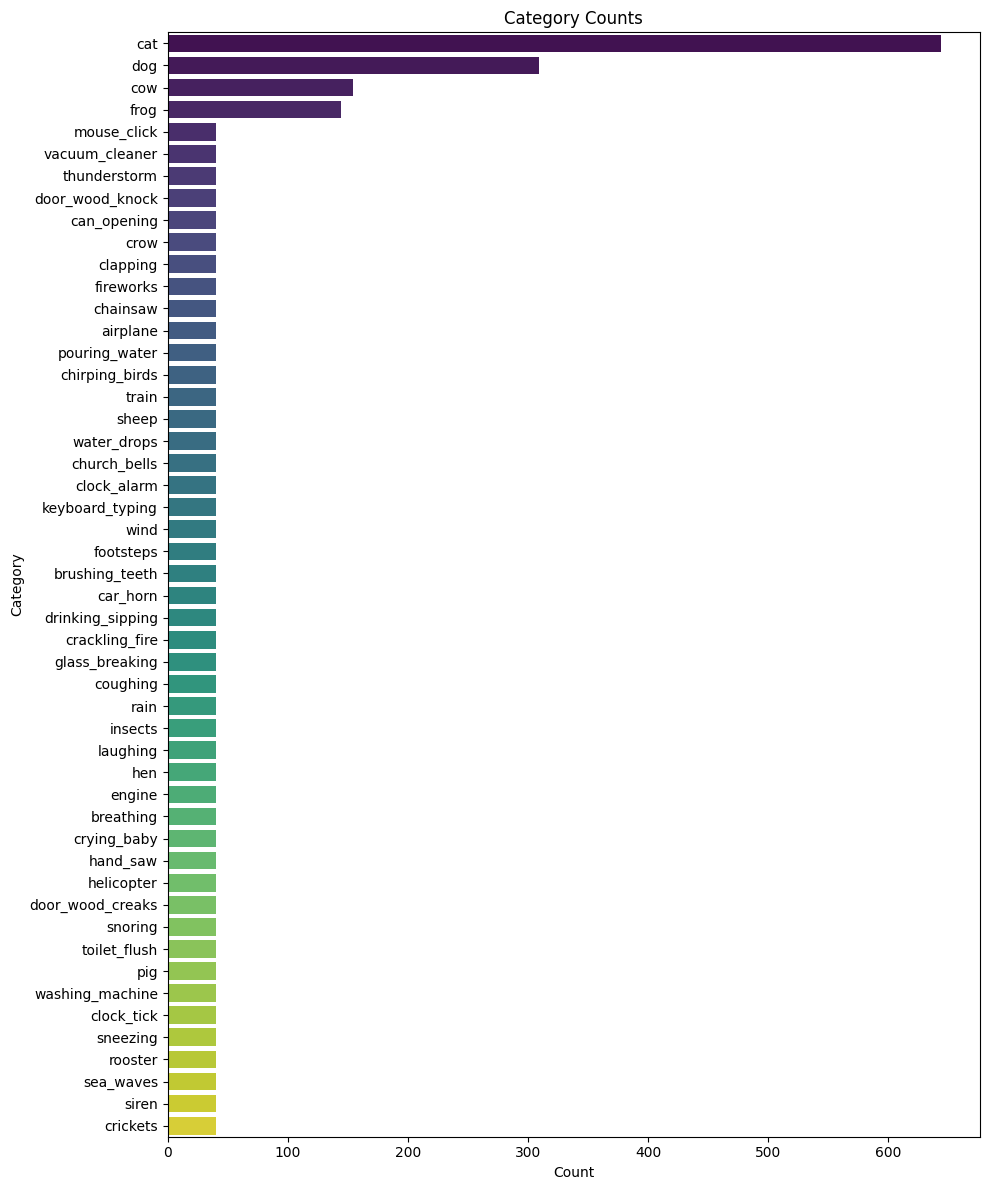

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data parsing
data_text = """
cat                 644
dog                 309
cow                 154
frog                144
coughing             40
rain                 40
insects              40
laughing             40
hen                  40
engine               40
breathing            40
crying_baby          40
hand_saw             40
glass_breaking       40
helicopter           40
snoring              40
toilet_flush         40
pig                  40
washing_machine      40
clock_tick           40
sneezing             40
rooster              40
sea_waves            40
siren                40
door_wood_creaks     40
drinking_sipping     40
crackling_fire       40
chirping_birds       40
mouse_click          40
vacuum_cleaner       40
thunderstorm         40
door_wood_knock      40
can_opening          40
crow                 40
clapping             40
fireworks            40
chainsaw             40
airplane             40
pouring_water        40
car_horn             40
train                40
sheep                40
water_drops          40
church_bells         40
clock_alarm          40
keyboard_typing      40
wind                 40
footsteps            40
brushing_teeth       40
crickets             40
""" # (truncated for brevity)

# Parse lines and create DataFrame
lines = data_text.strip().split('\n')
parsed_data = []
for line in lines:
    parts = line.rsplit(None, 1)
    if len(parts) == 2:
        category = parts[0]
        count = int(parts[1])
        parsed_data.append({'category': category, 'count': count})

df = pd.DataFrame(parsed_data)
df = df.sort_values(by='count', ascending=False)

# Plotting
fig, ax = plt.subplots(figsize=(10, 12))
sns.barplot(x='count', y='category', data=df, palette='viridis', ax=ax)
ax.set_title('Category Counts')
ax.set_xlabel('Count')
ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig('category_counts.png')

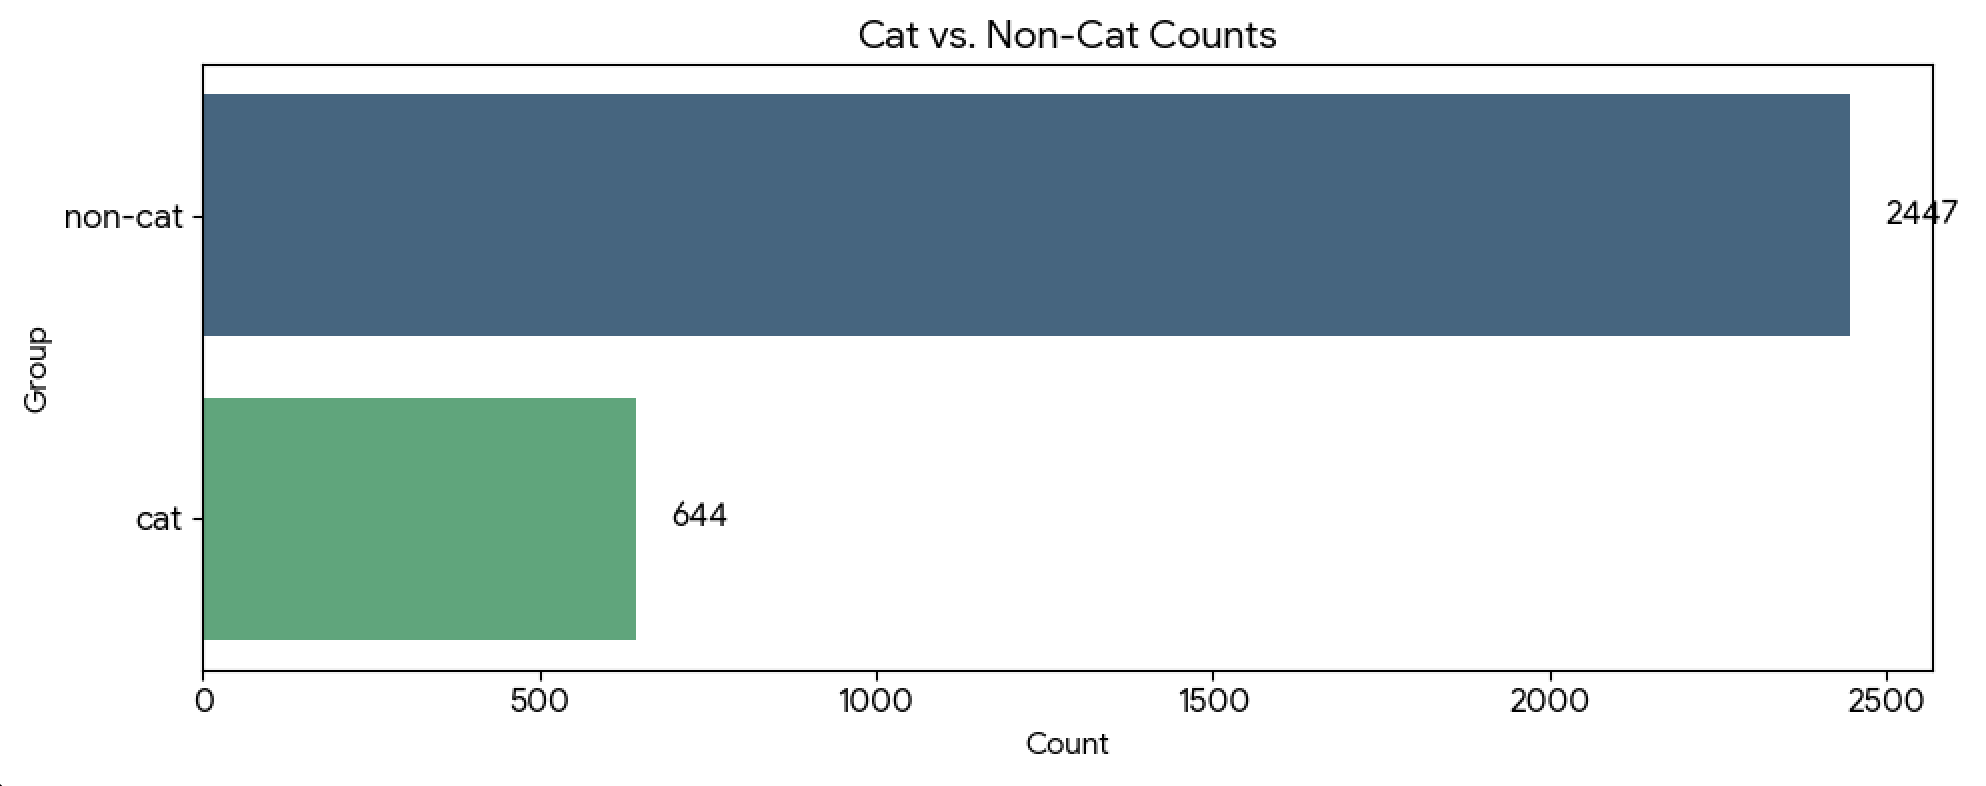

### Feature extraction

In [23]:
df.sample()

,filepath,category,fold,filename
1272,/Users/viktorzozula/.cache/kagglehub/datasets/...,church_bells,4.0,NaN


In [24]:
df['filepath'].iloc[8]

'/Users/viktorzozula/.cache/kagglehub/datasets/javohirtoshqorgonov/noise-audio-data/versions/1/ESC-50-master/audio/1-103298-A-9.wav'

In [25]:
formats = []
for i in range(df.shape[0]):
  formats.append(str(df['filepath'].iloc[i])[-4:])

In [26]:
set(formats)

{'.wav'}

In [27]:
df.shape

(3091, 4)

In [29]:
import librosa
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from pydub import AudioSegment
import io

In [30]:
# --- Параметри, які можуть вимагати налаштування ---
N_MFCC = 40                 # Кількість MFCC-коефіцієнтів
SAMPLE_RATE = 22050         # Частота дискретизації
# Фіксована кількість часових кадрів, до якої ми вирівнюємо.
# Наприклад, для 5-секундного кліпу при частоті 22050 Гц та довжині вікна 512,
# це приблизно 216 кадрів. Візьмемо ~174 кадри як безпечне значення для коротких кліпів.
MAX_MFCC_FRAMES = 174

In [31]:
def extract_features_pydub(file_path):
    """
    Витягує MFCCs, використовуючи pydub для завантаження аудіо (обхід проблеми з soundfile).
    """
    try:
        # 1. Завантаження аудіо через pydub (вимагає ffmpeg)
        # pydub завантажує файл у пам'ять
        audio_segment = AudioSegment.from_file(file_path)

        # Перетворення аудіосегменту на масив numpy для librosa
        # Приведення до потрібної частоти дискретизації та бітової глибини (16-bit)
        if audio_segment.frame_rate != SAMPLE_RATE:
            audio_segment = audio_segment.set_frame_rate(SAMPLE_RATE)

        if audio_segment.channels > 1:
            audio_segment = audio_segment.set_channels(1) # Перетворення на моно

        # Отримання сирих даних і перетворення на numpy масив
        audio_array = np.array(audio_segment.get_array_of_samples())

        # Нормалізація для librosa (з плаваючою комою)
        if audio_array.dtype.kind == 'i': # Перевірка, чи ціле число
            audio_float = audio_array.astype(np.float32) / (2**15)
        else:
            audio_float = audio_array.astype(np.float32)

        # 2. Вилучення MFCCs (тепер від librosa)
        mfccs = librosa.feature.mfcc(y=audio_float, sr=SAMPLE_RATE, n_mfcc=N_MFCC)

        # 3. Падінг/Обрізання, Усереднення
        mfccs = librosa.util.fix_length(mfccs, size=MAX_MFCC_FRAMES, axis=1)
        mfccs_processed = np.mean(mfccs.T, axis=0)

        return mfccs_processed

    except FileNotFoundError:
        print(f"❌ ФАЙЛ НЕ ЗНАЙДЕНО: {file_path}. Перевірте шлях.")
        return None
    except Exception as e:
        # Ця помилка тепер вказує, що pydub (і ffmpeg) не змогли прочитати файл.
        print(f"⚠️ ПОМИЛКА ДЕКОДУВАННЯ PYDUB ({e.__class__.__name__}): {file_path}. Файл, ймовірно, пошкоджений або має екзотичний формат.")
        return None

In [33]:
tqdm.pandas(desc="Вилучення MFCC-фіч")

df['features'] = df['filepath'].apply(
    lambda x: extract_features_pydub(x)
)

In [34]:
df.shape

(3091, 5)

In [35]:
# 1. Очищення: Видалення рядків, де виникла помилка під час обробки
df.dropna(subset=['features'], inplace=True)

In [36]:
# 2. Підготовка масивів NumPy (як раніше)
X = np.array(df['features'].tolist())
y = np.array(df['category'].tolist())

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\n✅ Вилучення фіч завершено.")
print(f"🔥 Форма масиву фіч (X): {X.shape} (тобто {X.shape[0]} зразків, {X.shape[1]} фіч)")
print(f"🔥 Усі вектори мають фіксовану довжину {X.shape[1]} і готові до моделей.")


✅ Вилучення фіч завершено.
🔥 Форма масиву фіч (X): (3091, 40) (тобто 3091 зразків, 40 фіч)
🔥 Усі вектори мають фіксовану довжину 40 і готові до моделей.


### Training

In [37]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from tqdm.notebook import tqdm
import numpy as np
import pandas as pd

In [38]:
# 1. Розділення на тренувальний та тестовий набори (20% для фінальної оцінки)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded # Важливо для збереження балансу класів у наборах
)

print(f"Тренувальний набір: {X_train.shape[0]} зразків")
print(f"Тестовий набір: {X_test.shape[0]} зразків")

Тренувальний набір: 2472 зразків
Тестовий набір: 619 зразків


In [ ]:
pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(solver='liblinear', random_state=42, max_iter=2000))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    'K-Nearest Neighbors (KNN)': Pipeline([
        ('scaler', StandardScaler()), # KNN чутливий до масштабу, стандартизація обов'язкова
        ('model', KNeighborsClassifier(n_neighbors=5, n_jobs=-1)) # Починаємо з K=5
    ]),
    'Gaussian Naive Bayes (GNB)': Pipeline([
        ('scaler', StandardScaler()), # GNB також чутливий до масштабу
        ('model', GaussianNB())
    ])
}

In [ ]:
# Налаштування K-Fold
num_folds = 5
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=42)

results = {}
scoring = 'f1_weighted'

In [ ]:
print("\n--- Починаємо Крос-валідацію (Метрика: F1-Score) ---")

# Проведення крос-валідації для кожної моделі з використанням TQDM
for name, pipeline in tqdm(pipelines.items(), desc="Моделі, що проходять CV"):
    # print(f"Обчислення для: **{name}**...") # Вивід замінено на tqdm

    # cross_val_score автоматично застосовує K-Fold
    cv_results = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=kfold,
        scoring=scoring,
        n_jobs=-1
    )
    results[name] = cv_results

    mean_f1 = cv_results.mean()
    std_f1 = cv_results.std()

    print(f"\n✔️ **{name}** середній F1-Score: **{mean_f1:.4f}** (стандартне відхилення: {std_f1:.4f})")
    print("---")


--- Починаємо Крос-валідацію (Метрика: F1-Score) ---


Моделі, що проходять CV:   0%|          | 0/4 [00:00<?, ?it/s]


✔️ **Logistic Regression** середній F1-Score: **0.3572** (стандартне відхилення: 0.0188)
---

✔️ **Random Forest** середній F1-Score: **0.4831** (стандартне відхилення: 0.0287)
---

✔️ **K-Nearest Neighbors (KNN)** середній F1-Score: **0.3906** (стандартне відхилення: 0.0123)
---

✔️ **Gaussian Naive Bayes (GNB)** середній F1-Score: **0.3680** (стандартне відхилення: 0.0204)
---


/tmp/ipython-input-2365616829.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(list(results.values()), labels=list(results.keys()))


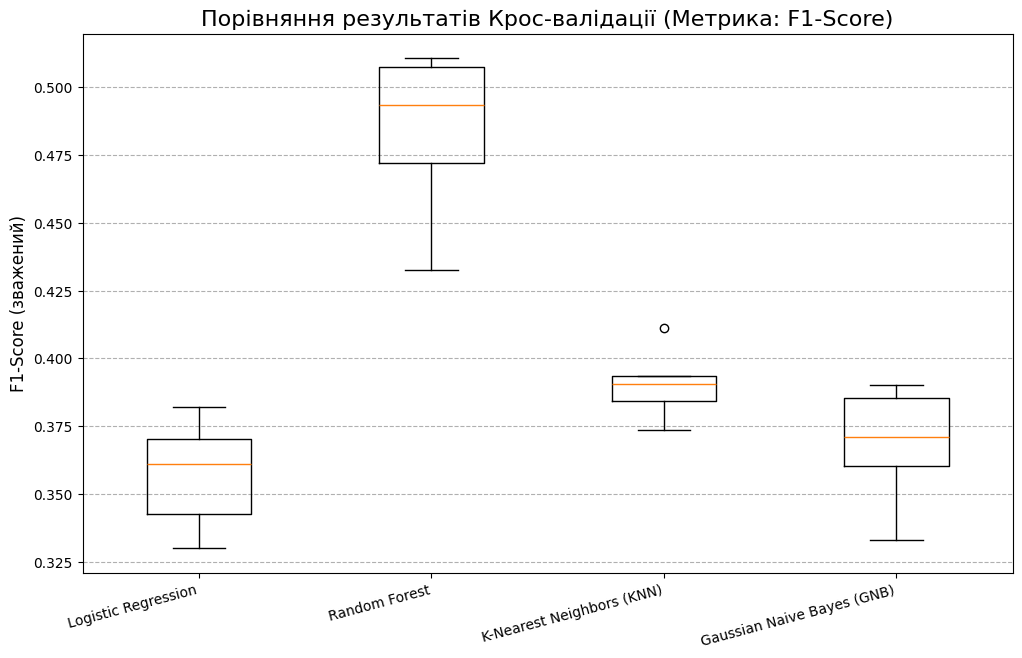

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))
ax.boxplot(list(results.values()), labels=list(results.keys()))
ax.set_title('Порівняння результатів Крос-валідації (Метрика: F1-Score)', fontsize=16)
ax.set_ylabel('F1-Score (зважений)', fontsize=12)
ax.grid(axis='y', linestyle='--')
plt.xticks(rotation=15, ha='right')
plt.show()

In [39]:
from sklearn.model_selection import GridSearchCV
from tqdm.auto import tqdm as tqdm_base
import time

In [40]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        random_state=42, n_jobs=-1, class_weight='balanced'
        )
    )
])

In [ ]:
param_grid = {
    # Параметри для моделі Random Forest, префікс 'model__' є обов'язковим
    'model__n_estimators': [50, 100, 200, 300],  # Кількість дерев
    'model__max_depth': [10, 20, 40, 80],   # None = повна глибина
    'model__min_samples_split': [2, 5, 10],     # Мінімальна кількість зразків для розбиття
    'model__criterion': ['gini', 'entropy'] # Функція для вимірювання якості розбиття
}

In [ ]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,           # Пайплайн
    param_grid=param_grid,           # Сітка параметрів
    scoring='f1_weighted',           # Цільова метрика
    cv=5,                            # 5-кратна крос-валідація
    verbose=4,                       # Детальний вивід
    n_jobs=-1                        # Використовувати всі доступні ядра
)

print(f"🔥 Починається Grid Search. Загальна кількість комбінацій для тестування: {len(param_grid['model__n_estimators']) * len(param_grid['model__max_depth']) * len(param_grid['model__min_samples_split']) * len(param_grid['model__criterion'])} * 5 фолдів.")

🔥 Починається Grid Search. Загальна кількість комбінацій для тестування: 96 * 5 фолдів.


In [ ]:
# Оцінка на Тестовому Наборі (використовуємо X_test, y_test)
best_rf_model = grid_search.best_estimator_
best_rf_model

In [ ]:
y_pred = best_rf_model.predict(X_test)

In [151]:
class_names = le.classes_
class_names

array(['airplane', 'breathing', 'brushing_teeth', 'can_opening',
       'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells',
       'clapping', 'clock_alarm', 'clock_tick', 'coughing', 'cow',
       'crackling_fire', 'crickets', 'crow', 'crying_baby', 'dog',
       'door_wood_creaks', 'door_wood_knock', 'drinking_sipping',
       'engine', 'fireworks', 'footsteps', 'frog', 'glass_breaking',
       'hand_saw', 'helicopter', 'hen', 'insects', 'keyboard_typing',
       'laughing', 'mouse_click', 'pig', 'pouring_water', 'rain',
       'rooster', 'sea_waves', 'sheep', 'siren', 'sneezing', 'snoring',
       'thunderstorm', 'toilet_flush', 'train', 'vacuum_cleaner',
       'washing_machine', 'water_drops', 'wind'], dtype='<U16')

In [ ]:
# 1. Обчислення Матриці Плутанини
# y_test та y_pred мають бути доступні з попереднього кроку
cm = confusion_matrix(y_test, y_pred)

# 2. Отримання міток (класів)
# Припускаємо, що le (LabelEncoder) та class_names доступні
try:
    class_names = le.classes_
except NameError:
    # Якщо LabelEncoder не доступний, використовуємо унікальні мітки
    class_names = np.unique(y_test)

# 3. Візуалізація
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,          # Додавання числових значень
    fmt='d',             # Формат цілих чисел
    cmap='Blues',        # Колірна схема
    xticklabels=class_names, # Мітки осі X (прогнозовані)
    yticklabels=class_names  # Мітки осі Y (фактичні)
)
plt.title('Матриця Плутанини для Random Forest (Тестовий набір)', fontsize=16)
plt.ylabel('Фактичний клас (True Label)', fontsize=12)
plt.xlabel('Прогнозований клас (Predicted Label)', fontsize=12)
plt.show()

Клас: 'cat' має ID: 5

In [ ]:
CAT_CLASS_ID = 5

y_test_binary = np.where(y_test == CAT_CLASS_ID, 1, 0)
y_pred_binary = np.where(y_pred == CAT_CLASS_ID, 1, 0)
binary_class_names = ['Non-Cat', 'Cat']

In [ ]:
# 2. Обчислення Матриці Плутанини
cm_binary = confusion_matrix(y_test_binary, y_pred_binary)

# 3. Візуалізація
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_binary,
    annot=True,              # Додавання числових значень
    fmt='d',                 # Формат цілих чисел
    cmap='Blues',
    xticklabels=binary_class_names, # Мітки осі X (Прогнозовані: Non-Cat, Cat)
    yticklabels=binary_class_names  # Мітки осі Y (Фактичні: Non-Cat, Cat)
)
plt.title('Матриця Плутанини (Cat vs Non-Cat) для Random Forest', fontsize=14)
plt.ylabel('Фактичний клас (True Label)', fontsize=12)
plt.xlabel('Прогнозований клас (Predicted Label)', fontsize=12)
plt.show() #

In [45]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Exception ignored in: <function tqdm.__del__ at 0x10b6b9c60>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


In [ ]:
print(classification_report(
    y_test_binary,
    y_pred_binary,
    target_names=binary_class_names,
    zero_division=0
))

### increasing threshold

In [ ]:
y_proba = best_rf_model.predict_proba(X_test)
cat_probabilities = y_proba[:, CAT_CLASS_ID]

new_threshold = 0.2
print(f"Використовується поріг: {new_threshold}")

In [ ]:
y_pred_binary = (cat_probabilities >= new_threshold).astype(int)
y_test_binary = np.where(y_test == CAT_CLASS_ID, 1, 0)

binary_class_names = ['Non-Cat', 'Cat']
cm_binary = confusion_matrix(y_test_binary, y_pred_binary)

In [ ]:
print("\n--- Звіт про Класифікацію (Cat vs Non-Cat) з НОВИМ ПОРОГОМ ---")
print(classification_report(
    y_test_binary,
    y_pred_binary,
    target_names=binary_class_names,
    zero_division=0
))

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_binary, annot=True, fmt='d', cmap='Blues',
    xticklabels=binary_class_names, yticklabels=binary_class_names
)
plt.title(f'Матриця Плутанини (Поріг: {new_threshold})', fontsize=14)
plt.ylabel('Фактичний клас', fontsize=12)
plt.xlabel('Прогнозований клас', fontsize=12)
plt.show()

In [ ]:
# Отримання ймовірностей для всіх класів
y_proba = best_rf_model.predict_proba(X_test)
# Ймовірності для цільового класу (Кіт)
cat_probabilities = y_proba[:, CAT_CLASS_ID]

# Фактичні бінарні мітки
y_test_binary = np.where(y_test == CAT_CLASS_ID, 1, 0)
binary_class_names = ['Non-Cat', 'Cat']

results_list = []
thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

print("--- ТЕСТУВАННЯ РІЗНИХ ПОРОГІВ КЛАСИФІКАЦІЇ ---")

for threshold in thresholds_to_test:
    # Створення бінарного прогнозу з новим порогом
    y_pred_binary = (cat_probabilities >= threshold).astype(int)

    # Обчислення метрик
    report = classification_report(
        y_test_binary,
        y_pred_binary,
        target_names=binary_class_names,
        output_dict=True,
        zero_division=0
    )

    # Обчислення Матриці Плутанини
    cm = confusion_matrix(y_test_binary, y_pred_binary)
    TN, FP, FN, TP = cm.ravel()

    # Збереження результатів для класу 'Cat'
    results_list.append({
        'Threshold': threshold,
        'Cat Precision': report['Cat']['precision'],
        'Cat Recall': report['Cat']['recall'],
        'Cat F1-Score': report['Cat']['f1-score'],
        'False Positives (FP)': FP,
        'False Negatives (FN)': FN
    })

# Виведення результатів у вигляді таблиці
results_df = pd.DataFrame(results_list)

print(results_df.to_markdown(index=False, floatfmt=".3f"))

print("\n📊 Аналіз: Оберіть поріг, який дає найвищий Cat Precision з прийнятним Cat Recall.")

## Add balanced field

In [41]:
rf_best_balanced = RandomForestClassifier(
  random_state=42,
  n_jobs=-1,
  class_weight='balanced',
  max_depth=40,
  n_estimators=300
)

In [42]:
rf_best_balanced.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,40
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
y_pred = rf_best_balanced.predict(X_test)

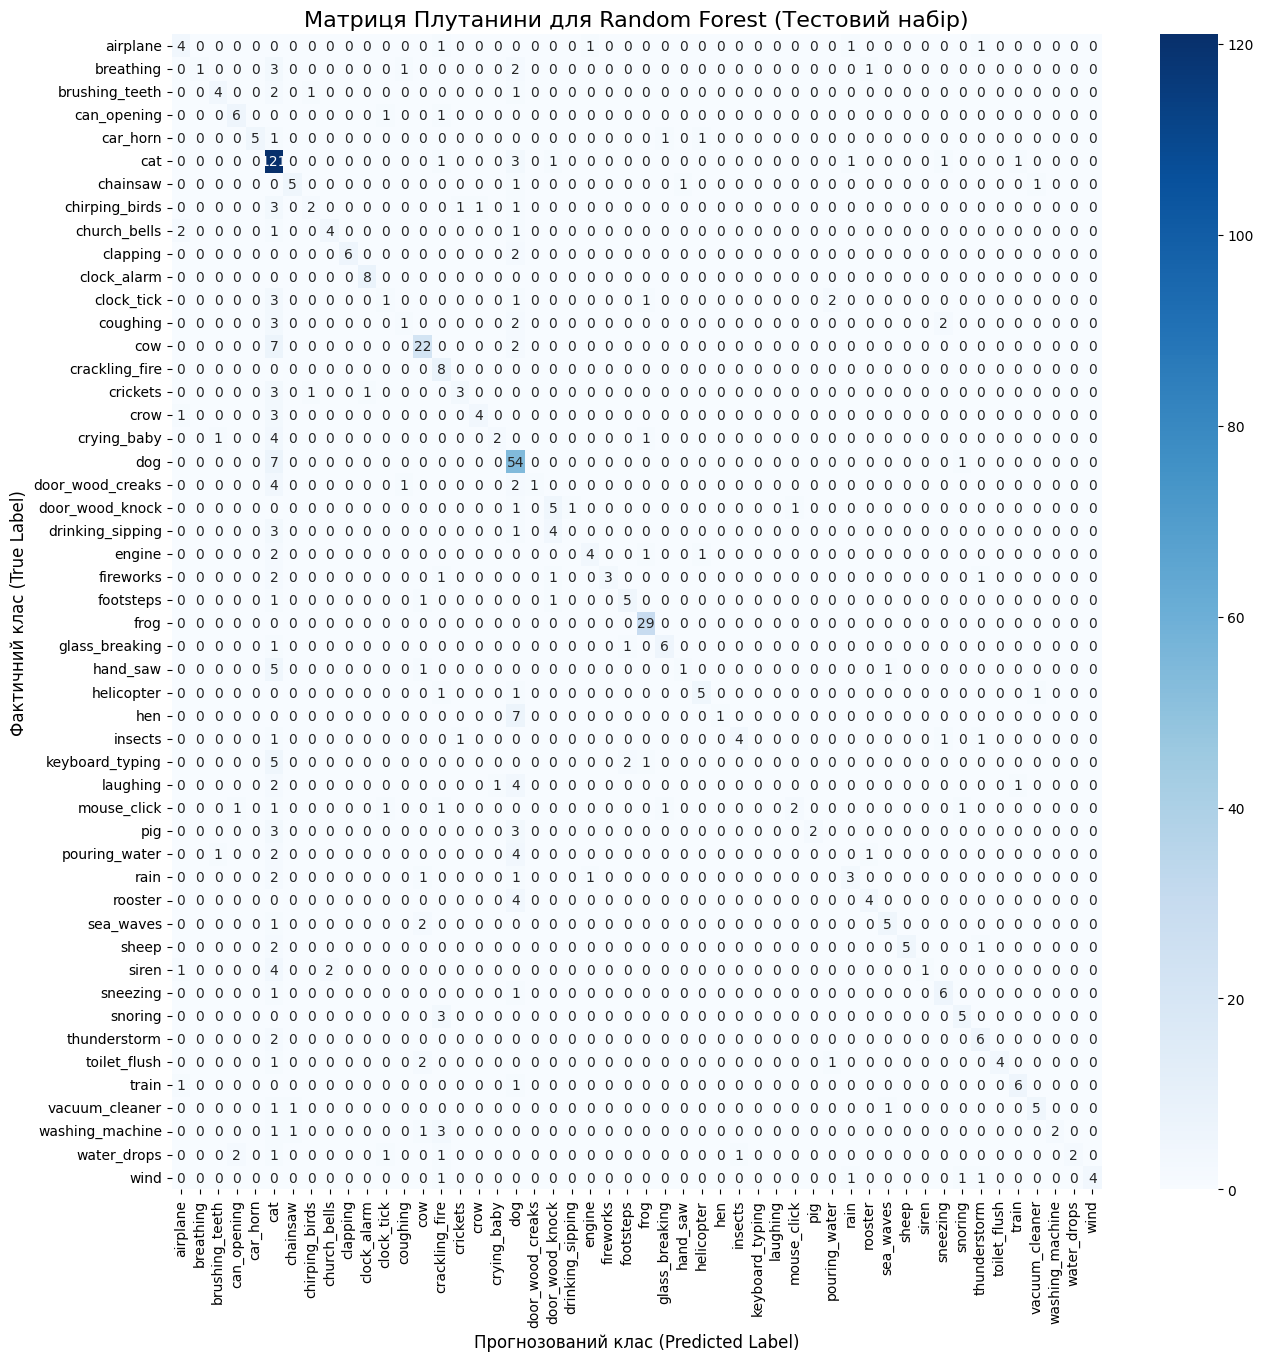

In [46]:
cm = confusion_matrix(y_test, y_pred)

# 2. Отримання міток (класів)
# Припускаємо, що le (LabelEncoder) та class_names доступні
try:
    class_names = le.classes_
except NameError:
    # Якщо LabelEncoder не доступний, використовуємо унікальні мітки
    class_names = np.unique(y_test)

# 3. Візуалізація
plt.figure(figsize=(15, 15))
sns.heatmap(
    cm,
    annot=True,          # Додавання числових значень
    fmt='d',             # Формат цілих чисел
    cmap='Blues',        # Колірна схема
    xticklabels=class_names, # Мітки осі X (прогнозовані)
    yticklabels=class_names  # Мітки осі Y (фактичні)
)
plt.title('Матриця Плутанини для Random Forest (Тестовий набір)', fontsize=16)
plt.ylabel('Фактичний клас (True Label)', fontsize=12)
plt.xlabel('Прогнозований клас (Predicted Label)', fontsize=12)
plt.show()

In [47]:
CAT_CLASS_ID = 5

y_test_binary = np.where(y_test == CAT_CLASS_ID, 1, 0)
y_pred_binary = np.where(y_pred == CAT_CLASS_ID, 1, 0)
binary_class_names = ['Non-Cat', 'Cat']

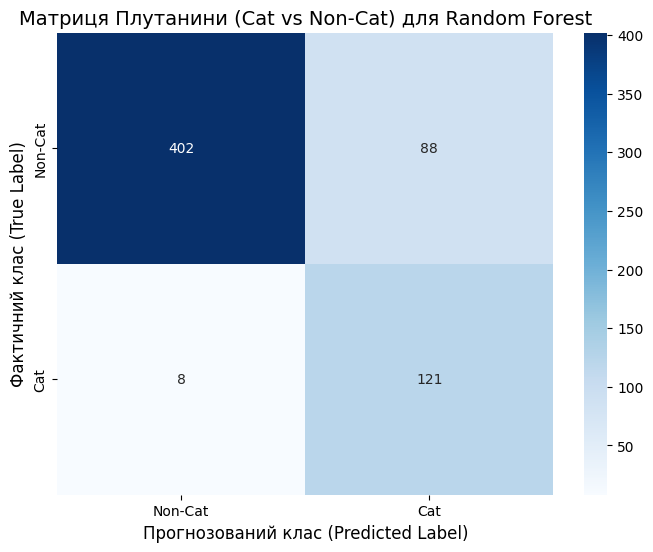

In [48]:
cm_binary = confusion_matrix(y_test_binary, y_pred_binary)

# 3. Візуалізація
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_binary,
    annot=True,              # Додавання числових значень
    fmt='d',                 # Формат цілих чисел
    cmap='Blues',
    xticklabels=binary_class_names, # Мітки осі X (Прогнозовані: Non-Cat, Cat)
    yticklabels=binary_class_names  # Мітки осі Y (Фактичні: Non-Cat, Cat)
)
plt.title('Матриця Плутанини (Cat vs Non-Cat) для Random Forest', fontsize=14)
plt.ylabel('Фактичний клас (True Label)', fontsize=12)
plt.xlabel('Прогнозований клас (Predicted Label)', fontsize=12)
plt.show() #

In [49]:
print(classification_report(
    y_test_binary,
    y_pred_binary,
    target_names=binary_class_names,
    zero_division=0
))

              precision    recall  f1-score   support

     Non-Cat       0.98      0.82      0.89       490
         Cat       0.58      0.94      0.72       129

    accuracy                           0.84       619
   macro avg       0.78      0.88      0.80       619
weighted avg       0.90      0.84      0.86       619



In [50]:
y_proba = rf_best_balanced.predict_proba(X_test)
cat_probabilities = y_proba[:, CAT_CLASS_ID]

new_threshold = 0.2
print(f"Використовується поріг: {new_threshold}")

Використовується поріг: 0.2


In [51]:
y_pred_binary = (cat_probabilities >= new_threshold).astype(int)
y_test_binary = np.where(y_test == CAT_CLASS_ID, 1, 0)

binary_class_names = ['Non-Cat', 'Cat']
cm_binary = confusion_matrix(y_test_binary, y_pred_binary)

In [52]:
print("\n--- Звіт про Класифікацію (Cat vs Non-Cat) з НОВИМ ПОРОГОМ ---")
print(classification_report(
    y_test_binary,
    y_pred_binary,
    target_names=binary_class_names,
    zero_division=0
))


--- Звіт про Класифікацію (Cat vs Non-Cat) з НОВИМ ПОРОГОМ ---
              precision    recall  f1-score   support

     Non-Cat       0.96      0.95      0.96       490
         Cat       0.82      0.84      0.83       129

    accuracy                           0.93       619
   macro avg       0.89      0.90      0.89       619
weighted avg       0.93      0.93      0.93       619



In [54]:
# Отримання ймовірностей для всіх класів
y_proba = rf_best_balanced.predict_proba(X_test)
# Ймовірності для цільового класу (Кіт)
cat_probabilities = y_proba[:, CAT_CLASS_ID]

# Фактичні бінарні мітки
y_test_binary = np.where(y_test == CAT_CLASS_ID, 1, 0)
binary_class_names = ['Non-Cat', 'Cat']

results_list = []
thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

print("--- ТЕСТУВАННЯ РІЗНИХ ПОРОГІВ КЛАСИФІКАЦІЇ ---")

for threshold in thresholds_to_test:
    # Створення бінарного прогнозу з новим порогом
    y_pred_binary = (cat_probabilities >= threshold).astype(int)

    # Обчислення метрик
    report = classification_report(
        y_test_binary,
        y_pred_binary,
        target_names=binary_class_names,
        output_dict=True,
        zero_division=0
    )

    # Обчислення Матриці Плутанини
    cm = confusion_matrix(y_test_binary, y_pred_binary)
    TN, FP, FN, TP = cm.ravel()

    # Збереження результатів для класу 'Cat'
    results_list.append({
        'Threshold': threshold,
        'Cat Precision': report['Cat']['precision'],
        'Cat Recall': report['Cat']['recall'],
        'Cat F1-Score': report['Cat']['f1-score'],
        'False Positives (FP)': FP,
        'False Negatives (FN)': FN
    })

# Виведення результатів у вигляді таблиці
results_df = pd.DataFrame(results_list)

print(results_df.to_markdown(index=False, floatfmt=".3f"))

print("\n📊 Аналіз: Оберіть поріг, який дає найвищий Cat Precision з прийнятним Cat Recall.")

--- ТЕСТУВАННЯ РІЗНИХ ПОРОГІВ КЛАСИФІКАЦІЇ ---
|   Threshold |   Cat Precision |   Cat Recall |   Cat F1-Score |   False Positives (FP) |   False Negatives (FN) |
|------------:|----------------:|-------------:|---------------:|-----------------------:|-----------------------:|
|       0.100 |           0.440 |        0.961 |          0.603 |                158.000 |                  5.000 |
|       0.200 |           0.824 |        0.837 |          0.831 |                 23.000 |                 21.000 |
|       0.300 |           0.979 |        0.713 |          0.825 |                  2.000 |                 37.000 |
|       0.400 |           1.000 |        0.651 |          0.789 |                  0.000 |                 45.000 |
|       0.500 |           1.000 |        0.643 |          0.783 |                  0.000 |                 46.000 |
|       0.600 |           1.000 |        0.636 |          0.777 |                  0.000 |                 47.000 |
|       0.700 |          

## New features

🛠️ Оновлена Функція Вилучення Фіч
Ми додамо наступні фічі від librosa та усереднимо їх, як і MFCCs:

Delta та Delta-Delta MFCCs: Динамічні зміни MFCCs.

Spectral Centroid: Геометричний центр маси спектру (сприймається як "яскравість").

Spectral Flatness: Міра того, наскільки спектр схожий на шум (ближче до 1) або на тон (ближче до 0).

Spectral Roll-off: Частота, нижче якої зосереджена певна частка енергії (наприклад, 85%).

In [55]:
import librosa
import numpy as np
from pydub import AudioSegment

In [56]:
SAMPLE_RATE = 22050
N_MFCC = 20
MAX_MFCC_FRAMES = 174

In [57]:
def extract_features_pydub(file_path):
    """
    Витягує MFCCs, Delta, Delta-Delta та Спектральні фічі.
    """
    try:
        # 1. Завантаження та підготовка аудіо (ваш існуючий блок)
        audio_segment = AudioSegment.from_file(file_path)

        # Перетворення частоти дискретизації, моно, 16-bit
        if audio_segment.frame_rate != SAMPLE_RATE:
            audio_segment = audio_segment.set_frame_rate(SAMPLE_RATE)
        if audio_segment.channels > 1:
            audio_segment = audio_segment.set_channels(1)

        audio_array = np.array(audio_segment.get_array_of_samples())
        audio_float = audio_array.astype(np.float32) / (2**15) # Нормалізація

        # 2. Обчислення STFT (Short-Time Fourier Transform)
        # Це потрібно для всіх спектральних фіч
        stft = np.abs(librosa.stft(audio_float))

        # --- ВИЛУЧЕННЯ ФІЧ (LIBROSA) ---

        # A. MFCCs (базові статичні)
        mfccs = librosa.feature.mfcc(y=audio_float, sr=SAMPLE_RATE, n_mfcc=N_MFCC)

        # B. Delta та Delta-Delta MFCCs (динамічні)
        mfccs_delta = librosa.feature.delta(mfccs)
        mfccs_delta2 = librosa.feature.delta(mfccs, order=2)

        # C. Спектральні фічі (тембральні)
        # Spectral Centroid (яскравість)
        centroid = librosa.feature.spectral_centroid(S=stft, sr=SAMPLE_RATE)
        # Spectral Flatness (шум vs тон)
        flatness = librosa.feature.spectral_flatness(S=stft)
        # Spectral Roll-off (розподіл енергії)
        rolloff = librosa.feature.spectral_rolloff(S=stft, sr=SAMPLE_RATE)

        # --- 3. ОБ'ЄДНАННЯ ТА УСЕРЕДНЕННЯ (Feature Aggregation) ---

        # 1. Створення єдиного масиву з усіх фреймів
        # Транспонуємо і усереднюємо всі матриці фіч

        # MFCCs та Delta MFCCs
        mfccs_mean = np.mean(mfccs.T, axis=0) # (N_MFCC,)
        mfccs_delta_mean = np.mean(mfccs_delta.T, axis=0) # (N_MFCC,)
        mfccs_delta2_mean = np.mean(mfccs_delta2.T, axis=0) # (N_MFCC,)

        # Спектральні фічі
        centroid_mean = np.mean(centroid.T, axis=0) # (1,)
        flatness_mean = np.mean(flatness.T, axis=0) # (1,)
        rolloff_mean = np.mean(rolloff.T, axis=0) # (1,)

        # 2. Конкатенація всіх усереднених фіч в один вектор
        # Використовуємо np.hstack для об'єднання всіх одновимірних масивів
        all_features = np.hstack([
            mfccs_mean,
            mfccs_delta_mean,
            mfccs_delta2_mean,
            centroid_mean,
            flatness_mean,
            rolloff_mean
        ])

        # Розмір вектора фіч: (N_MFCC * 3) + 3
        # Якщо N_MFCC=20: (20*3) + 3 = 63 фічі!

        return all_features

    except FileNotFoundError:
        print(f"❌ ФАЙЛ НЕ ЗНАЙДЕНО: {file_path}. Перевірте шлях.")
        return None
    except Exception as e:
        print(f"⚠️ ПОМИЛКА ДЕКОДУВАННЯ PYDUB/LIBROSA ({e.__class__.__name__}): {file_path}. {e}")
        return None

Після оновлення цієї функції вам потрібно:Запустити функцію extract_features_pydub для всіх ваших аудіофайлів (тренувальних та тестових).Переконатися, що ваш новий масив X_train та X_test тепер має 63 фічі (якщо $N_{MFCC}=20$) замість 20.Повторно навчити вашу найкращу модель Random Forest (або запустити Grid Search з class_weight='balanced'), щоб побачити, чи покращили нові фічі Precision та F1-Score для класу "Кіт".

In [58]:
df = pd.concat([df_1, df_2, df_3, df_4], ignore_index=True)

df['category'] = df['category'].apply(
    lambda category: category.lower()
)

In [60]:
tqdm.pandas(desc="Вилучення MFCC-фіч")

df['features'] = df['filepath'].apply(
    lambda x: extract_features_pydub(x)
)

In [61]:
df.shape

(3091, 5)

In [62]:
# 1. Очищення: Видалення рядків, де виникла помилка під час обробки
df.dropna(subset=['features'], inplace=True)

In [63]:
# 2. Підготовка масивів NumPy (як раніше)
X = np.array(df['features'].tolist())
y = np.array(df['category'].tolist())

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\n✅ Вилучення фіч завершено.")
print(f"🔥 Форма масиву фіч (X): {X.shape} (тобто {X.shape[0]} зразків, {X.shape[1]} фіч)")
print(f"🔥 Усі вектори мають фіксовану довжину {X.shape[1]} і готові до моделей.")


✅ Вилучення фіч завершено.
🔥 Форма масиву фіч (X): (3091, 63) (тобто 3091 зразків, 63 фіч)
🔥 Усі вектори мають фіксовану довжину 63 і готові до моделей.


In [64]:
# 1. Розділення на тренувальний та тестовий набори (20% для фінальної оцінки)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded # Важливо для збереження балансу класів у наборах
)

print(f"Тренувальний набір: {X_train.shape[0]} зразків")
print(f"Тестовий набір: {X_test.shape[0]} зразків")

Тренувальний набір: 2472 зразків
Тестовий набір: 619 зразків


In [65]:
# Налаштування K-Fold
num_folds = 5
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=42)

results = {}
scoring = 'f1_weighted'

In [66]:
pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            solver='liblinear',
            random_state=42,
            max_iter=2000,
            class_weight="balanced")
        )
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced")
        )
    ]),
    'K-Nearest Neighbors (KNN)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(
            n_neighbors=5)
        )
    ]),
    'Gaussian Naive Bayes (GNB)': Pipeline([
        ('scaler', StandardScaler()), # GNB також чутливий до масштабу
        ('model', GaussianNB())
    ])
}

In [ ]:
print("\n--- Починаємо Крос-валідацію (Метрика: F1-Score) ---")

# Проведення крос-валідації для кожної моделі з використанням TQDM
for name, pipeline in tqdm(pipelines.items(), desc="Моделі, що проходять CV"):
    # print(f"Обчислення для: **{name}**...") # Вивід замінено на tqdm
    # cross_val_score автоматично застосовує K-Fold
    cv_results = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=kfold,
        scoring=scoring,
        n_jobs=-1
    )

    results[name] = cv_results
    mean_f1 = cv_results.mean()
    std_f1 = cv_results.std()
    print(f"\n✔️ **{name}** середній F1-Score: **{mean_f1:.4f}** (стандартне відхилення: {std_f1:.4f})")
    print("---")


--- Починаємо Крос-валідацію (Метрика: F1-Score) ---


Моделі, що проходять CV:   0%|          | 0/4 [00:00<?, ?it/s]


✔️ **Logistic Regression** середній F1-Score: **0.4511** (стандартне відхилення: 0.0198)
---

✔️ **Random Forest** середній F1-Score: **0.4470** (стандартне відхилення: 0.0203)
---

✔️ **K-Nearest Neighbors (KNN)** середній F1-Score: **0.3990** (стандартне відхилення: 0.0158)
---

✔️ **Gaussian Naive Bayes (GNB)** середній F1-Score: **0.3862** (стандартне відхилення: 0.0044)
---


In [67]:
# RANDOM FOREST
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced")
    )
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

In [68]:
# Logistic Regression
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        solver='liblinear',
        random_state=42,
        max_iter=2000,
        class_weight="balanced")
    )
])

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


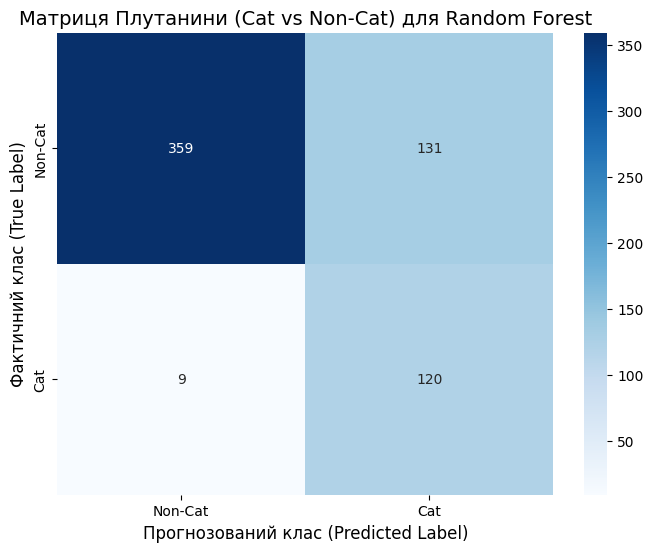

              precision    recall  f1-score   support

     Non-Cat       0.98      0.73      0.84       490
         Cat       0.48      0.93      0.63       129

    accuracy                           0.77       619
   macro avg       0.73      0.83      0.73       619
weighted avg       0.87      0.77      0.79       619



In [69]:
CAT_CLASS_ID = 5

y_test_binary = np.where(y_test == CAT_CLASS_ID, 1, 0)
y_pred_binary_rf = np.where(y_pred_rf == CAT_CLASS_ID, 1, 0)
binary_class_names = ['Non-Cat', 'Cat']

cm_binary = confusion_matrix(y_test_binary, y_pred_binary_rf)

# 3. Візуалізація
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_binary,
    annot=True,              # Додавання числових значень
    fmt='d',                 # Формат цілих чисел
    cmap='Blues',
    xticklabels=binary_class_names, # Мітки осі X (Прогнозовані: Non-Cat, Cat)
    yticklabels=binary_class_names  # Мітки осі Y (Фактичні: Non-Cat, Cat)
)
plt.title('Матриця Плутанини (Cat vs Non-Cat) для Random Forest', fontsize=14)
plt.ylabel('Фактичний клас (True Label)', fontsize=12)
plt.xlabel('Прогнозований клас (Predicted Label)', fontsize=12)
plt.show() #

print(classification_report(
    y_test_binary,
    y_pred_binary_rf,
    target_names=binary_class_names,
    zero_division=0
))


In [70]:
# Отримання ймовірностей для всіх класів
y_proba = rf_pipe.predict_proba(X_test)
# Ймовірності для цільового класу (Кіт)
cat_probabilities = y_proba[:, CAT_CLASS_ID]

# Фактичні бінарні мітки
y_test_binary = np.where(y_test == CAT_CLASS_ID, 1, 0)
binary_class_names = ['Non-Cat', 'Cat']

results_list = []
thresholds_to_test = [0.15, 0.175, 0.2, 0.225, 0.25, 0.275, 0.3, 0.4]

print("--- ТЕСТУВАННЯ РІЗНИХ ПОРОГІВ КЛАСИФІКАЦІЇ ---")

for threshold in thresholds_to_test:
    # Створення бінарного прогнозу з новим порогом
    y_pred_binary = (cat_probabilities >= threshold).astype(int)

    # Обчислення метрик
    report = classification_report(
        y_test_binary,
        y_pred_binary,
        target_names=binary_class_names,
        output_dict=True,
        zero_division=0
    )

    # Обчислення Матриці Плутанини
    cm = confusion_matrix(y_test_binary, y_pred_binary)
    TN, FP, FN, TP = cm.ravel()

    # Збереження результатів для класу 'Cat'
    results_list.append({
        'Threshold': threshold,
        'Cat Precision': report['Cat']['precision'],
        'Cat Recall': report['Cat']['recall'],
        'Cat F1-Score': report['Cat']['f1-score'],
        'False Positives (FP)': FP,
        'False Negatives (FN)': FN
    })

# Виведення результатів у вигляді таблиці
results_df = pd.DataFrame(results_list)

print(results_df.to_markdown(index=False, floatfmt=".3f"))

print("\n📊 Аналіз: Оберіть поріг, який дає найвищий Cat Precision з прийнятним Cat Recall.")

--- ТЕСТУВАННЯ РІЗНИХ ПОРОГІВ КЛАСИФІКАЦІЇ ---
|   Threshold |   Cat Precision |   Cat Recall |   Cat F1-Score |   False Positives (FP) |   False Negatives (FN) |
|------------:|----------------:|-------------:|---------------:|-----------------------:|-----------------------:|
|       0.150 |           0.571 |        0.930 |          0.708 |                 90.000 |                  9.000 |
|       0.175 |           0.653 |        0.891 |          0.754 |                 61.000 |                 14.000 |
|       0.200 |           0.693 |        0.876 |          0.774 |                 50.000 |                 16.000 |
|       0.225 |           0.812 |        0.837 |          0.824 |                 25.000 |                 21.000 |
|       0.250 |           0.841 |        0.822 |          0.831 |                 20.000 |                 23.000 |
|       0.275 |           0.870 |        0.775 |          0.820 |                 15.000 |                 29.000 |
|       0.300 |          

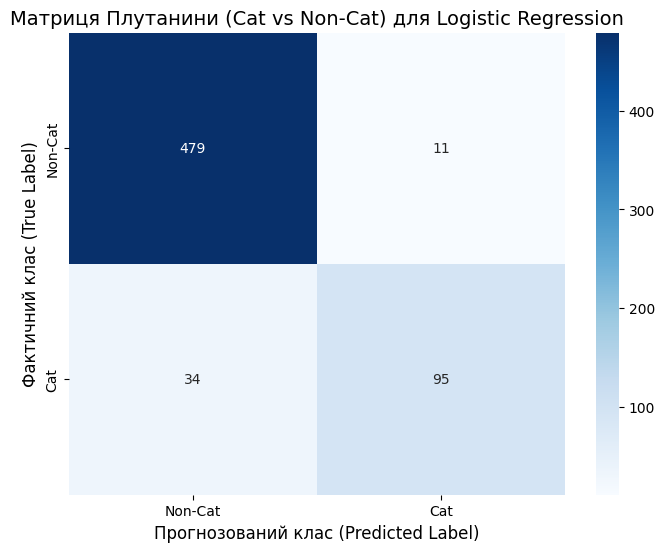

              precision    recall  f1-score   support

     Non-Cat       0.93      0.98      0.96       490
         Cat       0.90      0.74      0.81       129

    accuracy                           0.93       619
   macro avg       0.91      0.86      0.88       619
weighted avg       0.93      0.93      0.92       619



In [71]:
y_pred_binary_rf = (cat_probabilities >= 0.3).astype(int)
y_test_binary = np.where(y_test == CAT_CLASS_ID, 1, 0)

binary_class_names = ['Non-Cat', 'Cat']
cm_binary = confusion_matrix(y_test_binary, y_pred_binary)

cm_binary = confusion_matrix(y_test_binary, y_pred_binary_rf)

# 3. Візуалізація
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_binary,
    annot=True,              # Додавання числових значень
    fmt='d',                 # Формат цілих чисел
    cmap='Blues',
    xticklabels=binary_class_names, # Мітки осі X (Прогнозовані: Non-Cat, Cat)
    yticklabels=binary_class_names  # Мітки осі Y (Фактичні: Non-Cat, Cat)
)
plt.title('Матриця Плутанини (Cat vs Non-Cat) для Logistic Regression', fontsize=14)
plt.ylabel('Фактичний клас (True Label)', fontsize=12)
plt.xlabel('Прогнозований клас (Predicted Label)', fontsize=12)
plt.show() #

print(classification_report(
    y_test_binary,
    y_pred_binary_rf,
    target_names=binary_class_names,
    zero_division=0
))

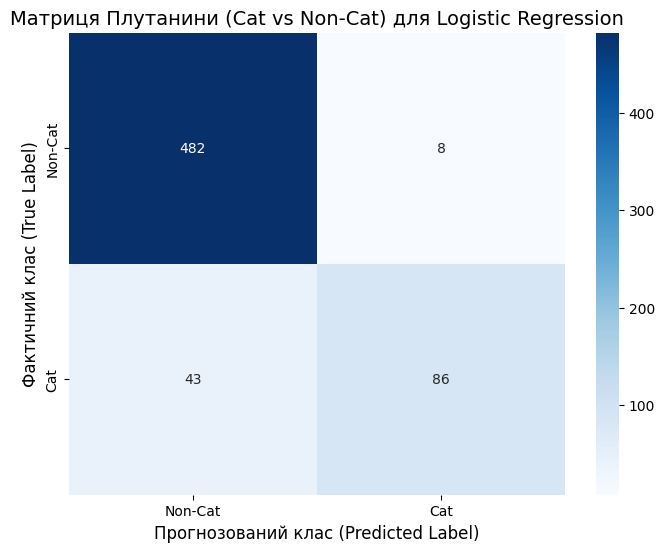

              precision    recall  f1-score   support

     Non-Cat       0.92      0.98      0.95       490
         Cat       0.91      0.67      0.77       129

    accuracy                           0.92       619
   macro avg       0.92      0.83      0.86       619
weighted avg       0.92      0.92      0.91       619



In [72]:
CAT_CLASS_ID = 5

y_pred_binary_lr = (cat_probabilities >= 0.175).astype(int)
y_test_binary = np.where(y_test == CAT_CLASS_ID, 1, 0)

binary_class_names = ['Non-Cat', 'Cat']
cm_binary = confusion_matrix(y_test_binary, y_pred_binary)

cm_binary = confusion_matrix(y_test_binary, y_pred_binary_lr)

y_test_binary = np.where(y_test == CAT_CLASS_ID, 1, 0)
y_pred_binary_lr = np.where(y_pred_lr == CAT_CLASS_ID, 1, 0)
binary_class_names = ['Non-Cat', 'Cat']

cm_binary = confusion_matrix(y_test_binary, y_pred_binary_lr)

# 3. Візуалізація
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_binary,
    annot=True,              # Додавання числових значень
    fmt='d',                 # Формат цілих чисел
    cmap='Blues',
    xticklabels=binary_class_names, # Мітки осі X (Прогнозовані: Non-Cat, Cat)
    yticklabels=binary_class_names  # Мітки осі Y (Фактичні: Non-Cat, Cat)
)
plt.title('Матриця Плутанини (Cat vs Non-Cat) для Logistic Regression', fontsize=14)
plt.ylabel('Фактичний клас (True Label)', fontsize=12)
plt.xlabel('Прогнозований клас (Predicted Label)', fontsize=12)
plt.show() #

print(classification_report(
    y_test_binary,
    y_pred_binary_lr,
    target_names=binary_class_names,
    zero_division=0
))


In [73]:
# Отримання ймовірностей для всіх класів
y_proba = lr_pipe.predict_proba(X_test)
# Ймовірності для цільового класу (Кіт)
cat_probabilities = y_proba[:, CAT_CLASS_ID]

# Фактичні бінарні мітки
y_test_binary = np.where(y_test == CAT_CLASS_ID, 1, 0)
binary_class_names = ['Non-Cat', 'Cat']

results_list = []
thresholds_to_test = [0.15, 0.175, 0.2, 0.225]

print("--- ТЕСТУВАННЯ РІЗНИХ ПОРОГІВ КЛАСИФІКАЦІЇ ---")

for threshold in thresholds_to_test:
    # Створення бінарного прогнозу з новим порогом
    y_pred_binary = (cat_probabilities >= threshold).astype(int)

    # Обчислення метрик
    report = classification_report(
        y_test_binary,
        y_pred_binary,
        target_names=binary_class_names,
        output_dict=True,
        zero_division=0
    )

    # Обчислення Матриці Плутанини
    cm = confusion_matrix(y_test_binary, y_pred_binary)
    TN, FP, FN, TP = cm.ravel()

    # Збереження результатів для класу 'Cat'
    results_list.append({
        'Threshold': threshold,
        'Cat Precision': report['Cat']['precision'],
        'Cat Recall': report['Cat']['recall'],
        'Cat F1-Score': report['Cat']['f1-score'],
        'False Positives (FP)': FP,
        'False Negatives (FN)': FN
    })

# Виведення результатів у вигляді таблиці
results_df = pd.DataFrame(results_list)

print(results_df.to_markdown(index=False, floatfmt=".3f"))

print("\n📊 Аналіз: Оберіть поріг, який дає найвищий Cat Precision з прийнятним Cat Recall.")

--- ТЕСТУВАННЯ РІЗНИХ ПОРОГІВ КЛАСИФІКАЦІЇ ---
|   Threshold |   Cat Precision |   Cat Recall |   Cat F1-Score |   False Positives (FP) |   False Negatives (FN) |
|------------:|----------------:|-------------:|---------------:|-----------------------:|-----------------------:|
|       0.150 |           0.863 |        0.682 |          0.762 |                 14.000 |                 41.000 |
|       0.175 |           0.867 |        0.659 |          0.749 |                 13.000 |                 44.000 |
|       0.200 |           0.894 |        0.651 |          0.753 |                 10.000 |                 45.000 |
|       0.225 |           0.921 |        0.636 |          0.752 |                  7.000 |                 47.000 |

📊 Аналіз: Оберіть поріг, який дає найвищий Cat Precision з прийнятним Cat Recall.


Making an ensamble model from logistic regression and randaom forest

RF with threshold 0.3
LR with threshold 0.175

## Adding Adaboost

In [83]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import VotingClassifier
import pickle

In [81]:
ada_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', AdaBoostClassifier(random_state=42))
])

In [ ]:
# Create a VotingClassifier with soft voting and weights
clf2 = VotingClassifier(
    estimators=[
        ('lr', lr_pipe),
        ('rf', rf_pipe),
        ('ada', ada_pipe)
    ],
    voting='soft',
    weights=[1, 1, 1]
    )

clf2.fit(X_train, y_train)
y_pred_soft = clf2.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


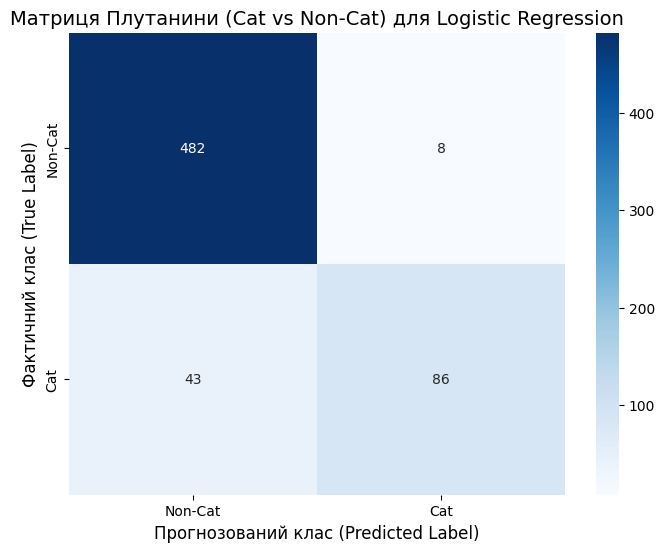

              precision    recall  f1-score   support

     Non-Cat       0.92      0.98      0.95       490
         Cat       0.91      0.67      0.77       129

    accuracy                           0.92       619
   macro avg       0.92      0.83      0.86       619
weighted avg       0.92      0.92      0.91       619



In [92]:
CAT_CLASS_ID = 5

y_test_binary = np.where(y_test == CAT_CLASS_ID, 1, 0)
y_pred_binary_ansemble = np.where(y_pred_lr == CAT_CLASS_ID, 1, 0)
binary_class_names = ['Non-Cat', 'Cat']

cm_binary = confusion_matrix(y_test_binary, y_pred_binary_ansemble)

# 3. Візуалізація
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_binary,
    annot=True,              # Додавання числових значень
    fmt='d',                 # Формат цілих чисел
    cmap='Blues',
    xticklabels=binary_class_names, # Мітки осі X (Прогнозовані: Non-Cat, Cat)
    yticklabels=binary_class_names  # Мітки осі Y (Фактичні: Non-Cat, Cat)
)
plt.title('Матриця Плутанини (Cat vs Non-Cat) для Logistic Regression', fontsize=14)
plt.ylabel('Фактичний клас (True Label)', fontsize=12)
plt.xlabel('Прогнозований клас (Predicted Label)', fontsize=12)
plt.show() #

print(classification_report(
    y_test_binary,
    y_pred_binary_ansemble,
    target_names=binary_class_names,
    zero_division=0
))


In [118]:
df.sample()

,filepath,category,fold,filename,features
1590,/Users/viktorzozula/.cache/kagglehub/datasets/...,siren,4.0,NaN,"[-306.4937744140625, 29.023303985595703, -135...."


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3091 entries, 0 to 3090
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   filepath  3091 non-null   object 
 1   category  3091 non-null   object 
 2   fold      2000 non-null   float64
 3   filename  1091 non-null   object 
 4   features  3091 non-null   object 
dtypes: float64(1), object(4)
memory usage: 120.9+ KB


In [119]:
df.to_csv("audio_cat-noncat_dataframe.csv")

## З чистого листа

In [94]:
# 1. Розділення на тренувальний та тестовий набори (20% для фінальної оцінки)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.25,
    random_state=42,
    stratify=y_encoded # Важливо для збереження балансу класів у наборах
)

print(f"Тренувальний набір: {X_train.shape[0]} зразків")
print(f"Тестовий набір: {X_test.shape[0]} зразків")

Тренувальний набір: 2318 зразків
Тестовий набір: 773 зразків


In [95]:
from sklearn.ensemble import RandomForestClassifier

rf_cls = RandomForestClassifier(
    random_state=42,

)
rf_cls.fit(X_train, y_train)
y_pred_rf = rf_cls.predict(X_test)

In [99]:
print(classification_report(
    y_true=y_test,
    y_pred=y_pred_rf,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.75      0.30      0.43        10
           1       1.00      0.30      0.46        10
           2       0.42      0.50      0.45        10
           3       0.30      0.30      0.30        10
           4       0.00      0.00      0.00        10
           5       0.59      0.91      0.72       161
           6       0.20      0.10      0.13        10
           7       0.50      0.30      0.38        10
           8       0.38      0.30      0.33        10
           9       0.46      0.60      0.52        10
          10       0.70      0.70      0.70        10
          11       0.67      0.20      0.31        10
          12       0.30      0.30      0.30        10
          13       0.63      0.69      0.66        39
          14       0.38      0.60      0.46        10
          15       0.33      0.30      0.32        10
          16       1.00      0.40      0.57        10
          17       0.75    

In [ ]:
def binary_classification_report(y_true, y_pred):
    y_test_binary = np.where(y_true == CAT_CLASS_ID, 1, 0)
    y_pred_binary_rf = np.where(y_pred == CAT_CLASS_ID, 1, 0)
    
    binary_class_names = ['Non-Cat', 'Cat']
    return classification_report(
        y_true=y_test_binary,
        y_pred=y_pred_binary_rf,
        zero_division=0
    )

In [105]:
print(binary_classification_report(
    y_true=y_test,
    y_pred=y_pred_rf
))

              precision    recall  f1-score   support

           0       0.97      0.83      0.90       612
           1       0.59      0.91      0.72       161

    accuracy                           0.85       773
   macro avg       0.78      0.87      0.81       773
weighted avg       0.89      0.85      0.86       773



In [112]:
def create_train_return_classifier(
    classifier_class_name,
    **kwargs
):
    cls = classifier_class_name(
        random_state=42,
        **kwargs
    )
    cls.fit(X_train, y_train)
    y_pred = cls.predict(X_test)

    print(binary_classification_report(
        y_true=y_test,
        y_pred=y_pred
    ))

    return cls

In [117]:
from sklearn.linear_model import LogisticRegression
import math

lr_cls = create_train_return_classifier(
    LogisticRegression,
    max_iter = 100_000
)

              precision    recall  f1-score   support

           0       0.95      0.92      0.93       612
           1       0.72      0.81      0.76       161

    accuracy                           0.90       773
   macro avg       0.83      0.87      0.85       773
weighted avg       0.90      0.90      0.90       773



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 14513 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [130]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgdb_cls = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

hgdb_cls.fit(X_train, y_train)
y_pred_hgdb = hgdb_cls.predict(X_test)

In [131]:
print(binary_classification_report(
    y_true=y_test,
    y_pred=y_pred_hgdb
))

              precision    recall  f1-score   support

           0       0.97      0.86      0.91       612
           1       0.63      0.91      0.75       161

    accuracy                           0.87       773
   macro avg       0.80      0.89      0.83       773
weighted avg       0.90      0.87      0.88       773



In [132]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)

print(binary_classification_report(y_test, y_dummy))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       612
           1       0.21      1.00      0.34       161

    accuracy                           0.21       773
   macro avg       0.10      0.50      0.17       773
weighted avg       0.04      0.21      0.07       773



In [148]:
final_cls = Pipeline([
    ("scaler", StandardScaler()),
    ("voting", VotingClassifier(
        estimators=[
            (
                'lr',
                LogisticRegression(
                    random_state=42,
                    solver="lbfgs"
                )
            ),
            (
                'rf',
                RandomForestClassifier(
                    random_state=42
                )
            ),
            (
                'hgb',
                HistGradientBoostingClassifier(
                    random_state=42
                )
            )
        ],
        voting="soft",
        weights=[1, 1, 1]
    ))
])

final_cls.fit(X_train, y_train)
y_final = final_cls.predict(X_test)

print(binary_classification_report(y_test, y_final))

Exception ignored in: <function tqdm.__del__ at 0x10b6b9c60>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


              precision    recall  f1-score   support

           0       0.98      0.91      0.94       612
           1       0.72      0.91      0.81       161

    accuracy                           0.91       773
   macro avg       0.85      0.91      0.87       773
weighted avg       0.92      0.91      0.91       773



5️⃣ Why this grid works (and won’t lie to you)
✅ Logistic Regression

C: controls regularization strength

class_weight: critical for imbalance

✅ Random Forest

max_depth: prevents overfitting

min_samples_leaf: stabilizes splits

✅ HistGradientBoosting

learning_rate × max_depth: core bias–variance tradeoff

✅ Voting weights

Lets the ensemble learn trust

Often LR or RF should dominate, not equal weights

In [145]:
param_grid = {
    # Logistic Regression
    "voting__lr__C": [0.1, 1.0, 10.0],
    "voting__lr__class_weight": [None, "balanced"],

    # Random Forest
    "voting__rf__max_depth": [4, 6, None],
    "voting__rf__min_samples_leaf": [1, 5],

    # HistGradientBoosting
    "voting__hgb__max_depth": [4, 6],
    "voting__hgb__learning_rate": [0.05, 0.1],

    # Voting weights
    "voting__weights": [
        [1, 1, 1],
        [2, 1, 1],
        [1, 2, 1],
        [1, 1, 2],
    ]
}

In [146]:
grid = GridSearchCV(
    estimator=final_cls,
    param_grid=param_grid,
    scoring="f1_macro",   
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 576 candidates, totalling 1728 fits


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
   

,estimator,"Pipeline(step...=[1, 1, 1]))])"
,param_grid,"{'voting__hgb__learning_rate': [0.05, 0.1], 'voting__hgb__max_depth': [4, 6], 'voting__lr__C': [0.1, 1.0, ...], 'voting__lr__class_weight': [None, 'balanced'], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [147]:
best_cls = grid.best_estimator_

y_final = best_cls.predict(X_test)

print("Best params:")
print(grid.best_params_)

print(binary_classification_report(y_test, y_final))


Best params:
{'voting__hgb__learning_rate': 0.1, 'voting__hgb__max_depth': 6, 'voting__lr__C': 1.0, 'voting__lr__class_weight': 'balanced', 'voting__rf__max_depth': None, 'voting__rf__min_samples_leaf': 1, 'voting__weights': [1, 2, 1]}
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       612
           1       0.69      0.89      0.78       161

    accuracy                           0.89       773
   macro avg       0.83      0.89      0.85       773
weighted avg       0.91      0.89      0.90       773



In [149]:
import joblib

# Save to file
joblib.dump(final_cls, "voting_classifier.pkl")
print("✅ VotingClassifier saved!")

✅ VotingClassifier saved!


In [225]:
final_cls

,steps,"[('scaler', ...), ('voting', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'soft'
,weights,"[1, 1, ...]"
,n_jobs,None


# Retraining Classifing

In [212]:
import ast

df_additional = pd.read_csv("audio_cat-emotion_dataframe_sample.csv")
df_additional['features'] = df_additional['features'].apply(ast.literal_eval)

In [213]:
df_additional['feat_len'] = df_additional['features'].apply(len)
print(df_additional['feat_len'].value_counts())

feat_len
63    593
Name: count, dtype: int64


In [214]:
df.shape, df_additional.shape

((3091, 6), (593, 6))

In [215]:
df['feat_len'] = df['features'].apply(len)
print(df['feat_len'].value_counts())

feat_len
63    3091
Name: count, dtype: int64


In [216]:
df_new = pd.concat([df, df_additional], ignore_index=True)
df_new.shape

(3684, 9)

In [217]:
df_new.dropna(subset=['features'], inplace=True)
df_new.shape

(3684, 9)

In [218]:
df_new['feat_len'] = df_new['features'].apply(len)
print(df_new['feat_len'].value_counts())

feat_len
63    3684
Name: count, dtype: int64


In [219]:
# 2. Підготовка масивів NumPy (як раніше)
X = np.array(df_new['features'].tolist())
y = np.array(df_new['category'].tolist())

In [220]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [221]:
# 1. Розділення на тренувальний та тестовий набори (20% для фінальної оцінки)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.25,
    random_state=42,
    stratify=y_encoded # Важливо для збереження балансу класів у наборах
)

print(f"Тренувальний набір: {X_train.shape[0]} зразків")
print(f"Тестовий набір: {X_test.shape[0]} зразків")

Тренувальний набір: 2763 зразків
Тестовий набір: 921 зразків


In [222]:
final_cls = Pipeline([
    ("scaler", StandardScaler()),
    ("voting", VotingClassifier(
        estimators=[
            (
                'lr',
                LogisticRegression(
                    random_state=42,
                    solver="lbfgs"
                )
            ),
            (
                'rf',
                RandomForestClassifier(
                    random_state=42
                )
            ),
            (
                'hgb',
                HistGradientBoostingClassifier(
                    random_state=42
                )
            )
        ],
        voting="soft",
        weights=[1, 1, 1]
    ))
])

final_cls.fit(X_train, y_train)
y_final = final_cls.predict(X_test)

print(binary_classification_report(y_test, y_final))

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.96      0.68      0.79       612
           1       0.60      0.94      0.73       309

    accuracy                           0.77       921
   macro avg       0.78      0.81      0.76       921
weighted avg       0.84      0.77      0.77       921



In [224]:
import joblib

# Save to file
joblib.dump(final_cls, "models/audio_preclassifier/voting_classifier_with-add-data.pkl")
print("✅ VotingClassifier saved!")

✅ VotingClassifier saved!
